<a href="https://colab.research.google.com/github/josemotta84/Entrega_guia_2_ML/blob/main/Entrega_guia_2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombres de los integrantes del grupo



*   Miguel Alejandro Díaz Cely
*   Jose Fernando motta Mendez
*   Emily Del Carmen Tench Pérez




In [1]:
# Primero se empieza definiendo el path donde se encuentran los archivos con la data
from google.colab import drive
drive.mount('/content/drive')

ruta_datos = '/content/drive/MyDrive/Colab Notebooks/Data_machine_learning_1/heart.csv'

Mounted at /content/drive


In [2]:
# Se importan las liberias necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Carga de la data y EDA basico

datos_heart_disease = pd.read_csv(ruta_datos)

print(datos_heart_disease.info()) # --> esto muestra un overview de la data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [4]:
# Cantidad total de datos vacios (null)
print(f" La cantidad de datos nulos en cada variable es: \n {datos_heart_disease.isnull().sum()}")

 La cantidad de datos nulos en cada variable es: 
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# Descripcion estadistica
print(datos_heart_disease.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

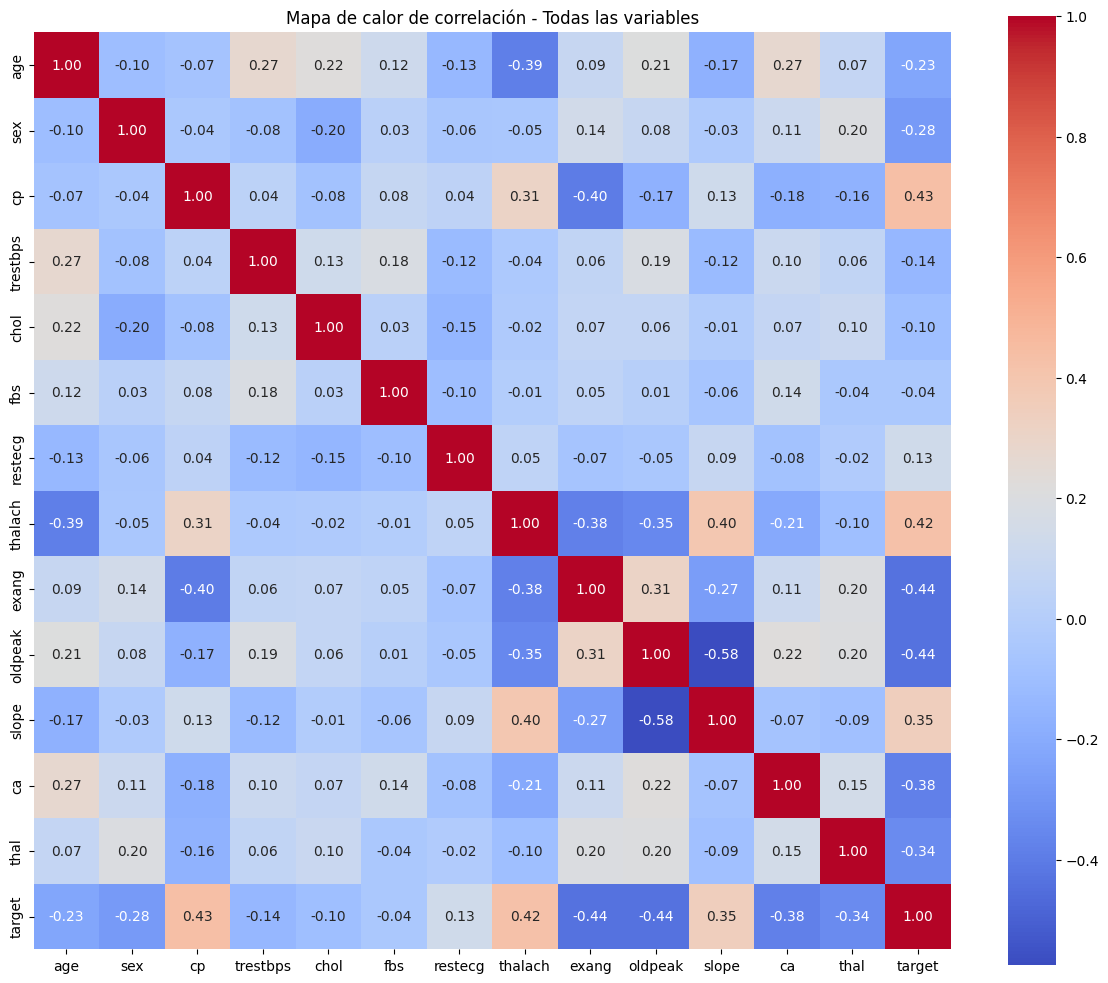

In [6]:
# Mapa de calor para identificar correlaciones y variables clave
# Se obtiene la matriz de correlacion de las variables numericas
matriz_correlacion = datos_heart_disease.select_dtypes(include='number').corr()

# Graficar el mapa de calor completo, es decir con todas las variables
plt.figure(figsize=(12,10))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Mapa de calor de correlación - Todas las variables")
plt.tight_layout()
plt.show()

In [7]:
# Parte 2 ----> seleccion de caracteristicas
# Se separa X e y
x = datos_heart_disease.drop(columns='target')
y = datos_heart_disease['target']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Se aplica SelectKBest
selector_kbest = SelectKBest(score_func=f_classif, k=10)
X_kbest = selector_kbest.fit_transform(x_scaled, y)

# Visualizacion de las variables que fueron seleccionadas
selected_features_kbest = x.columns[selector_kbest.get_support()]
print("🟩 SelectKBest - Variables seleccionadas:", selected_features_kbest.tolist())

🟩 SelectKBest - Variables seleccionadas: ['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [8]:
# Se utiliza la misma x_scaled y y
modelo = LogisticRegression(max_iter=1000)
selector_rfe = RFE(modelo, n_features_to_select=10)
selector_rfe.fit(x_scaled, y)

selected_features_rfe = x.columns[selector_rfe.support_]
print("🟩 SelectKBest - Variables seleccionadas:", selected_features_kbest.tolist())
print("🟩 RFE - Variables seleccionadas:", selected_features_rfe.tolist())

# Comparacion para ver que variables aparecen en ambas listas
interseccion = set(selected_features_kbest).intersection(set(selected_features_rfe))
print("Variables comunes en ambos métodos:", list(interseccion))


🟩 SelectKBest - Variables seleccionadas: ['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
🟩 RFE - Variables seleccionadas: ['sex', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Variables comunes en ambos métodos: ['cp', 'exang', 'thal', 'oldpeak', 'trestbps', 'slope', 'thalach', 'sex', 'ca']


Variables que fueron seleccionadas -->['sex', 'thalach', 'slope', 'thal', 'oldpeak', 'trestbps', 'ca', 'cp', 'exang']

Estas 9 variables fueron seleccionadas consistentemente por ambos métodos, lo cual refuerza su importancia. Representan factores clínicos bien conocidos por su asociación con enfermedades cardíacas: por ejemplo, thalach (frecuencia cardiaca máxima alcanzada), oldpeak (depresión del ST), y ca (número de vasos coloreados).

In [14]:
# Modelado y evaluacion con arbol de justificacion

#Lista de variables que fueron seleccionadas en ambos metodos
variables_seleccionadas = ['sex', 'thalach', 'slope', 'thal', 'oldpeak', 'trestbps', 'ca', 'cp', 'exang']

# Features y target
x = datos_heart_disease[variables_seleccionadas]
y = datos_heart_disease['target']

# Se separan los features del target
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

# Se divide el dataframe para reservar una parte para el entrenamiento y la otra para test
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
# Predicciones en el conjunto de entrenamiento
y_train_pred = modelo_arbol.predict(x_train)

# Evaluación en entrenamiento
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Training Precision:", precision_score(y_train, y_train_pred))
print("Training Recall:", recall_score(y_train, y_train_pred))
print("Training F1 Score:", f1_score(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))


Training Accuracy: 0.875609756097561
Training Precision: 0.8474945533769063
Training Recall: 0.9239904988123515
Training F1 Score: 0.884090909090909

Training Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.82      0.87       399
           1       0.85      0.92      0.88       421

    accuracy                           0.88       820
   macro avg       0.88      0.87      0.87       820
weighted avg       0.88      0.88      0.88       820



In [30]:
# Entrenamiento del arbol de decision
# Crear y entrenar el modelo
modelo_arbol = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_split=10)
modelo_arbol.fit(x_train, y_train)

# Predicciones
y_pred = modelo_arbol.predict(x_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8390243902439024
Precision: 0.8214285714285714
Recall: 0.8761904761904762
F1 Score: 0.847926267281106

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



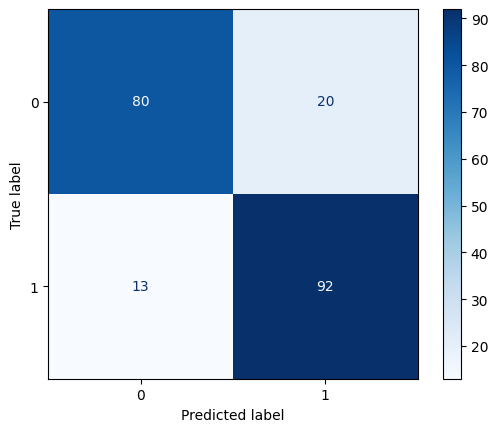

In [18]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

In [19]:
# Nivel avanzado, implementacion de gridsearch
param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10, 20]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)

# Reentrenar con mejores hiperparámetros
mejor_modelo = grid_search.best_estimator_
y_pred_mejor = mejor_modelo.predict(x_test)

print("F1 con mejor modelo:", f1_score(y_test, y_pred_mejor))

Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 2}
F1 con mejor modelo: 1.0


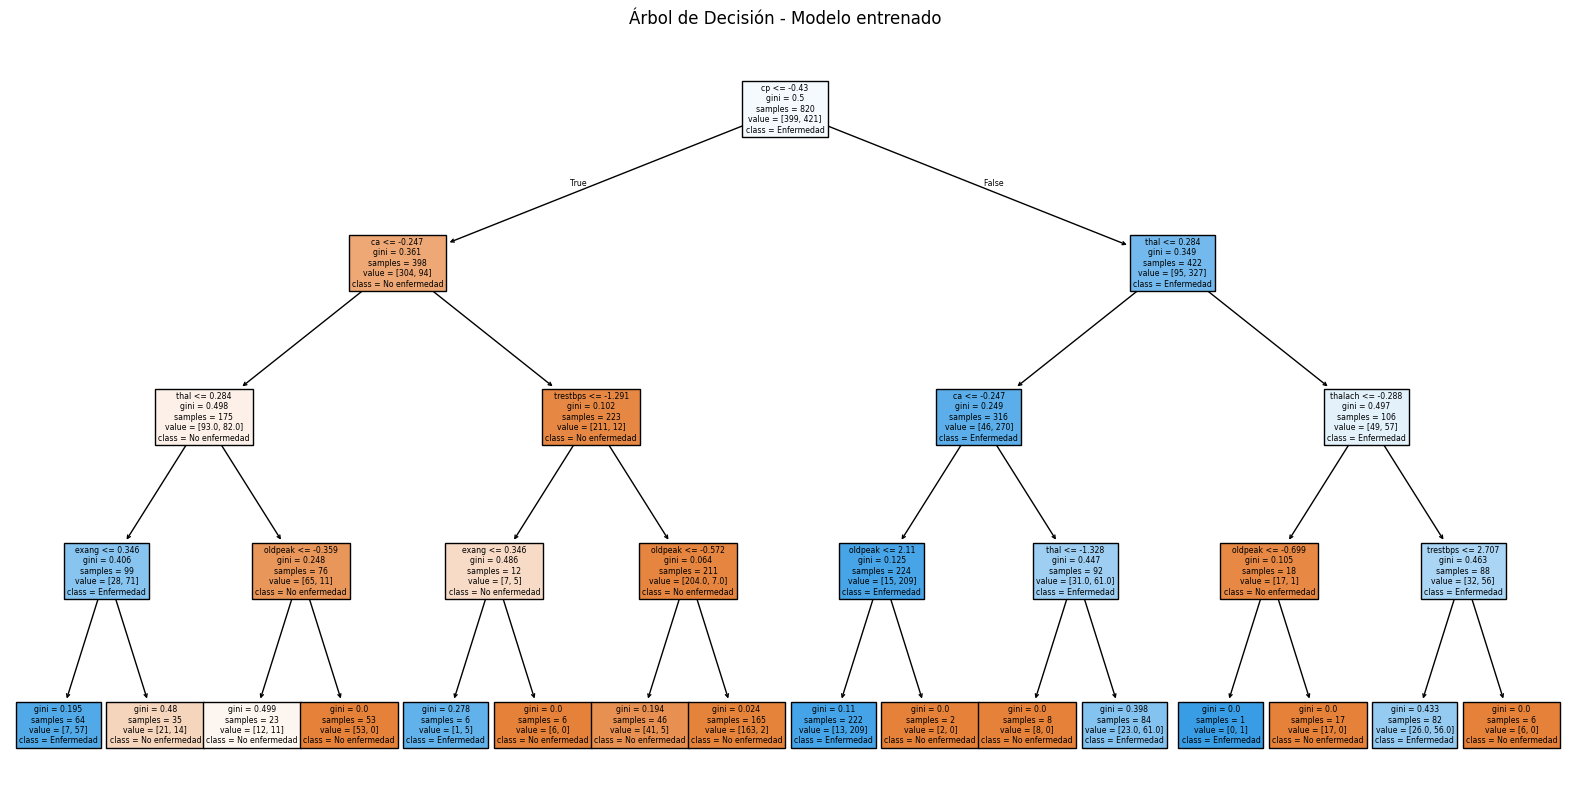

In [20]:
# Visualizacion del arbol
plt.figure(figsize=(20,10))
plot_tree(modelo_arbol, feature_names=variables_seleccionadas, class_names=['No enfermedad', 'Enfermedad'], filled=True)
plt.title("Árbol de Decisión - Modelo entrenado")
plt.show()

In [21]:
# Modelado y evaluacion con SVM ---> kernel lineal
# SVM con kernel lineal
modelo_svm_lineal = SVC(kernel='linear', C=1.0, random_state=42)
modelo_svm_lineal.fit(x_train, y_train)

# Predicción
y_pred_lineal = modelo_svm_lineal.predict(x_test)

# Evaluación
print("🔹 SVM - Kernel Lineal")
print("Accuracy:", accuracy_score(y_test, y_pred_lineal))
print("Precision:", precision_score(y_test, y_pred_lineal))
print("Recall:", recall_score(y_test, y_pred_lineal))
print("F1 Score:", f1_score(y_test, y_pred_lineal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lineal))


🔹 SVM - Kernel Lineal
Accuracy: 0.8292682926829268
Precision: 0.7868852459016393
Recall: 0.9142857142857143
F1 Score: 0.8458149779735683

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.74      0.81       100
           1       0.79      0.91      0.85       105

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



In [22]:
# Predicciones en el conjunto de entrenamiento
y_train_pred_lineal = modelo_svm_lineal.predict(x_train)

# Evaluación en entrenamiento
print("🔹 SVM - Kernel Lineal (Entrenamiento)")
print("Accuracy:", accuracy_score(y_train, y_train_pred_lineal))
print("Precision:", precision_score(y_train, y_train_pred_lineal))
print("Recall:", recall_score(y_train, y_train_pred_lineal))
print("F1 Score:", f1_score(y_train, y_train_pred_lineal))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_lineal))


🔹 SVM - Kernel Lineal (Entrenamiento)
Accuracy: 0.8597560975609756
Precision: 0.8283261802575107
Recall: 0.9168646080760094
F1 Score: 0.8703494926719278

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.80      0.85       399
           1       0.83      0.92      0.87       421

    accuracy                           0.86       820
   macro avg       0.86      0.86      0.86       820
weighted avg       0.86      0.86      0.86       820



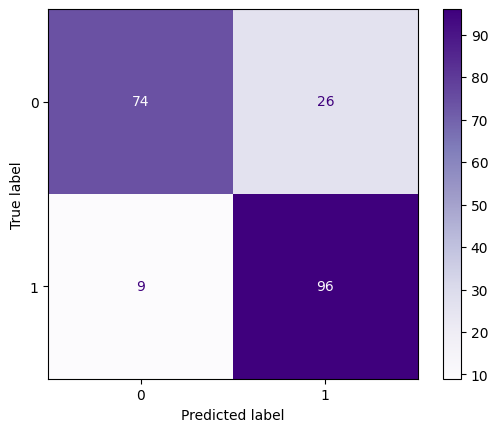

In [ ]:
# Matriz de confusion para el kernel lineal
cm_svm = confusion_matrix(y_test, y_pred_lineal)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap='Purples')

In [23]:
# Modelado y evaluacion con SVM ---> kernel RBF radial
# SVM con kernel RBF
modelo_svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
modelo_svm_rbf.fit(x_train, y_train)

# Predicción
y_pred_rbf = modelo_svm_rbf.predict(x_test)

# Evaluación
print("🔹 SVM - Kernel RBF")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall:", recall_score(y_test, y_pred_rbf))
print("F1 Score:", f1_score(y_test, y_pred_rbf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rbf))

🔹 SVM - Kernel RBF
Accuracy: 0.9170731707317074
Precision: 0.9150943396226415
Recall: 0.9238095238095239
F1 Score: 0.919431279620853

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91       100
           1       0.92      0.92      0.92       105

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.92      0.92      0.92       205



In [24]:
# Predicciones en el conjunto de entrenamiento
y_train_pred_rbf = modelo_svm_rbf.predict(x_train)

# Evaluación en entrenamiento
print("🔹 SVM - Kernel RBF (Entrenamiento)")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rbf))
print("Precision:", precision_score(y_train, y_train_pred_rbf))
print("Recall:", recall_score(y_train, y_train_pred_rbf))
print("F1 Score:", f1_score(y_train, y_train_pred_rbf))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred_rbf))


🔹 SVM - Kernel RBF (Entrenamiento)
Accuracy: 0.9292682926829269
Precision: 0.9115646258503401
Recall: 0.9548693586698337
F1 Score: 0.9327146171693735

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.93       399
           1       0.91      0.95      0.93       421

    accuracy                           0.93       820
   macro avg       0.93      0.93      0.93       820
weighted avg       0.93      0.93      0.93       820



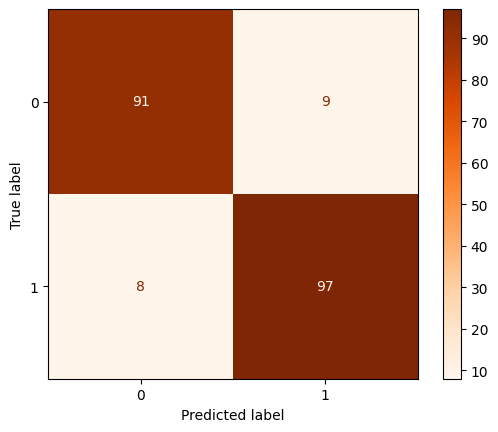

In [ ]:
# Matriz de confusion Kernel RBF
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf)
disp_rbf.plot(cmap='Oranges')

In [27]:
# Uso de gridsearchcv para encontrar la mejor combinacion de parametros
# Rango de valores para probar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

#Crear el modelo base
modelo_svm = SVC(random_state=42)

# Crear GridSearch
grid_search = GridSearchCV(modelo_svm, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Entrenar en el conjunto de entrenamiento
grid_search.fit(x_train, y_train)

# Mostrar mejores parámetros
print("🔍 Mejores parámetros encontrados:")
print(grid_search.best_params_)

🔍 Mejores parámetros encontrados:
{'C': 100, 'gamma': 1, 'kernel': 'rbf'}


In [26]:
# Evaluacion del mejor modelo
# Usar el mejor modelo para predecir
mejor_modelo_svm = grid_search.best_estimator_
y_pred_mejor = mejor_modelo_svm.predict(x_test)

# Evaluación
print("📊 Resultados con los mejores hiperparámetros (SVM-RBF optimizado)")
print("Accuracy:", accuracy_score(y_test, y_pred_mejor))
print("Precision:", precision_score(y_test, y_pred_mejor))
print("Recall:", recall_score(y_test, y_pred_mejor))
print("F1 Score:", f1_score(y_test, y_pred_mejor))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mejor))

📊 Resultados con los mejores hiperparámetros (SVM-RBF optimizado)
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.9714285714285714
F1 Score: 0.9855072463768116

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



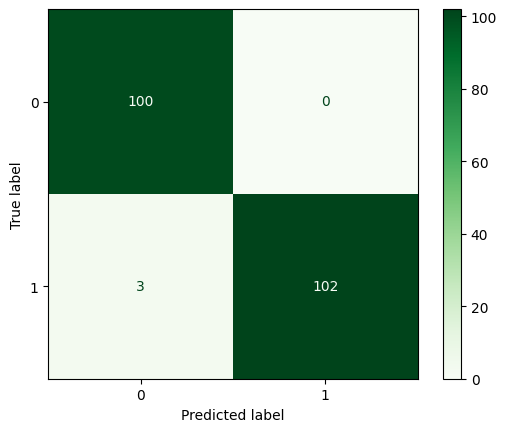

In [ ]:
# Matriz de confusion para el modelo svm optimizado
cm_mejor = confusion_matrix(y_test, y_pred_mejor)
disp_mejor = ConfusionMatrixDisplay(confusion_matrix=cm_mejor)
disp_mejor.plot(cmap='Greens')

### Regularización en SVM (Parámetro C)

- El parámetro **C** controla la **tolerancia al error de clasificación**.
  - Un **C alto** penaliza fuertemente los errores y tiende a sobreajustar (menos margen, más precisión en entrenamiento).
  - Un **C bajo** permite un margen más amplio, tolerando errores en entrenamiento, lo que puede mejorar la **generalización**.

### Kernel RBF vs Lineal
- **Kernel Lineal**: útil si los datos son aproximadamente separables en línea recta en el espacio de características.
- **Kernel RBF**: transforma los datos a un espacio de mayor dimensión donde pueden ser separados no linealmente. Puede capturar relaciones más complejas.


In [28]:
# Aplicar un StandardScaler para estandarizar variables y comparar mejoras en SVM.
# Entrenamiento del modelo sin escalar
x_no_scaled = datos_heart_disease[variables_seleccionadas]
y = datos_heart_disease['target']

x_train_ns, x_test_ns, y_train_ns, y_test_ns = train_test_split(x_no_scaled, y, test_size=0.2, random_state=42, stratify=y)

modelo_svm_sin_scaler = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
modelo_svm_sin_scaler.fit(x_train_ns, y_train_ns)

y_pred_ns = modelo_svm_sin_scaler.predict(x_test_ns)

print("📉 SVM SIN escalado")
print("Accuracy:", accuracy_score(y_test_ns, y_pred_ns))
print("Precision:", precision_score(y_test_ns, y_pred_ns))
print("Recall:", recall_score(y_test_ns, y_pred_ns))
print("F1 Score:", f1_score(y_test_ns, y_pred_ns))

📉 SVM SIN escalado
Accuracy: 0.7024390243902439
Precision: 0.6896551724137931
Recall: 0.7619047619047619
F1 Score: 0.7239819004524887


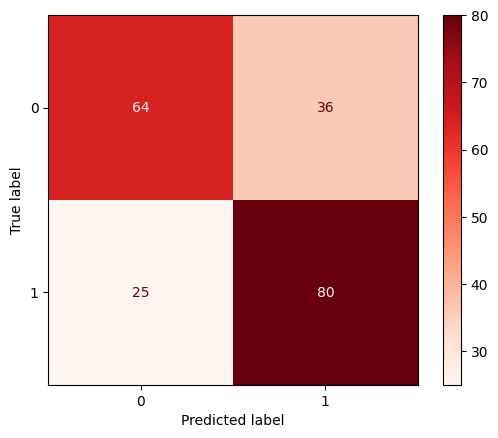

In [ ]:
# Matriz de confusion para el modelo no escalado
cm_ns = confusion_matrix(y_test_ns, y_pred_ns)
disp_ns = ConfusionMatrixDisplay(confusion_matrix=cm_ns)
disp_ns.plot(cmap='Reds')

In [ ]:
# Entrenamiento del modelo escalado
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x_no_scaled), columns=variables_seleccionadas)

x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

modelo_svm_con_scaler = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
modelo_svm_con_scaler.fit(x_train_s, y_train_s)

y_pred_s = modelo_svm_con_scaler.predict(x_test_s)

print("\n📈 SVM CON escalado")
print("Accuracy:", accuracy_score(y_test_s, y_pred_s))
print("Precision:", precision_score(y_test_s, y_pred_s))
print("Recall:", recall_score(y_test_s, y_pred_s))
print("F1 Score:", f1_score(y_test_s, y_pred_s))


📈 SVM CON escalado
Accuracy: 0.9170731707317074
Precision: 0.9150943396226415
Recall: 0.9238095238095239
F1 Score: 0.919431279620853


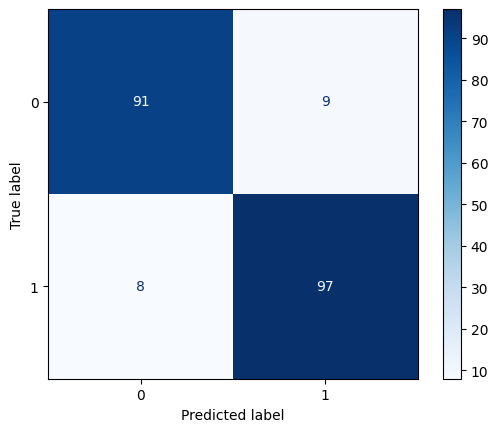

In [ ]:
# Matriz de confusion para el modelo escalado
cm_s = confusion_matrix(y_test_s, y_pred_s)
disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s)
disp_s.plot(cmap='Blues')

In [ ]:
# Comparacion de resultados
resultados = pd.DataFrame({
    'Modelo': ['SVM sin escalado', 'SVM con escalado'],
    'Accuracy': [accuracy_score(y_test_ns, y_pred_ns), accuracy_score(y_test_s, y_pred_s)],
    'Precision': [precision_score(y_test_ns, y_pred_ns), precision_score(y_test_s, y_pred_s)],
    'Recall': [recall_score(y_test_ns, y_pred_ns), recall_score(y_test_s, y_pred_s)],
    'F1 Score': [f1_score(y_test_ns, y_pred_ns), f1_score(y_test_s, y_pred_s)]
})
print(resultados)

             Modelo  Accuracy  Precision    Recall  F1 Score
0  SVM sin escalado  0.702439   0.689655  0.761905  0.723982
1  SVM con escalado  0.917073   0.915094  0.923810  0.919431


### Comparación: SVM con y sin escalado

- El modelo SVM mostró **mejor rendimiento tras aplicar StandardScaler**, ya que el algoritmo es sensible a la escala de las variables.
- Al estandarizar, se iguala la importancia relativa de cada variable y se mejora la capacidad del kernel RBF para trazar una frontera de decisión eficiente.
- Por lo tanto, se recomienda **siempre escalar las variables** al trabajar con SVM.


###Reflexion sobre overfitting y underfitting

Dado que los datos del dataset estaban limpios, los modelos (como el árbol de decisión y las SVM con distintos kernels) mostraron un buen desempeño tanto en el conjunto de entrenamiento como en el de prueba. Esto sugiere que los modelos están generalizando bien y no hay señales evidentes de sobreajuste.

En este caso, optimizar ciertos hiperparámetros podría no ser estrictamente necesario, ya que podría llevar a un sobreajuste si se busca una mejora mínima en métricas sobre datos ya bien estructurados.

Sin embargo, en la mayoría de los casos reales donde los datos no están completamente limpios o presentan ruido, **la optimización de parámetros (como `C`, `gamma` o `max_depth`) puede ser muy útil** para:
- Mejorar el rendimiento del modelo
- Reducir el sobreajuste o el subajuste
- Adaptar mejor el modelo a las características específicas del dataset

Por lo tanto, aunque en este experimento la optimización no sea crítica, en contextos más realistas es una etapa fundamental del pipeline de modelado.